In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/AAPL_stock_market_trend_dataset.csv")
data.head()

,Date,Open,High,Low,Close,Volume,MA_50,MA_200,Daily_Return,Target_Close
0,2022-03-22,115.13,115.88,114.42,115.10,72851093,114.34,111.13,-1.67,115.77
1,2022-03-23,115.07,116.57,112.82,115.77,113852247,114.53,111.10,0.58,116.81
2,2022-03-24,117.04,117.71,115.26,116.81,129151722,114.72,111.08,0.90,118.76
3,2022-03-25,119.43,120.72,118.15,118.76,113964268,114.98,111.07,1.67,120.70
4,2022-03-28,122.05,123.41,119.58,120.70,91588083,115.27,111.05,1.63,118.26


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1104 entries, 0 to 1103
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          1104 non-null   object 
 1   Open          1104 non-null   float64
 2   High          1104 non-null   float64
 3   Low           1104 non-null   float64
 4   Close         1104 non-null   float64
 5   Volume        1104 non-null   int64  
 6   MA_50         1104 non-null   float64
 7   MA_200        1104 non-null   float64
 8   Daily_Return  1104 non-null   float64
 9   Target_Close  1104 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 86.4+ KB


In [4]:
data.describe()

,Open,High,Low,Close,Volume,MA_50,MA_200,Daily_Return,Target_Close
count,1104.000000,1104.000000,1104.000000,1104.000000,1.104000e+03,1104.000000,1104.000000,1104.000000,1104.000000
mean,212.416694,215.401911,209.375145,212.393542,1.006651e+08,205.765652,186.385272,0.128379,212.671993
std,96.384516,97.693790,94.945946,96.284327,2.892165e+07,91.661115,75.809943,1.497521,96.447075
min,115.070000,115.880000,112.820000,115.100000,5.011691e+07,114.340000,110.830000,-4.810000,115.770000
25%,141.120000,143.042500,139.210000,141.240000,7.634597e+07,140.655000,140.820000,-0.890000,141.280000
50%,157.165000,159.390000,154.805000,157.135000,1.016680e+08,155.165000,149.060000,0.120000,157.140000
75%,283.202500,287.657500,279.397500,282.827500,1.260707e+08,252.790000,220.245000,1.080000,284.442500
max,436.820000,442.350000,432.010000,434.670000,1.499544e+08,411.080000,387.510000,5.830000,434.670000


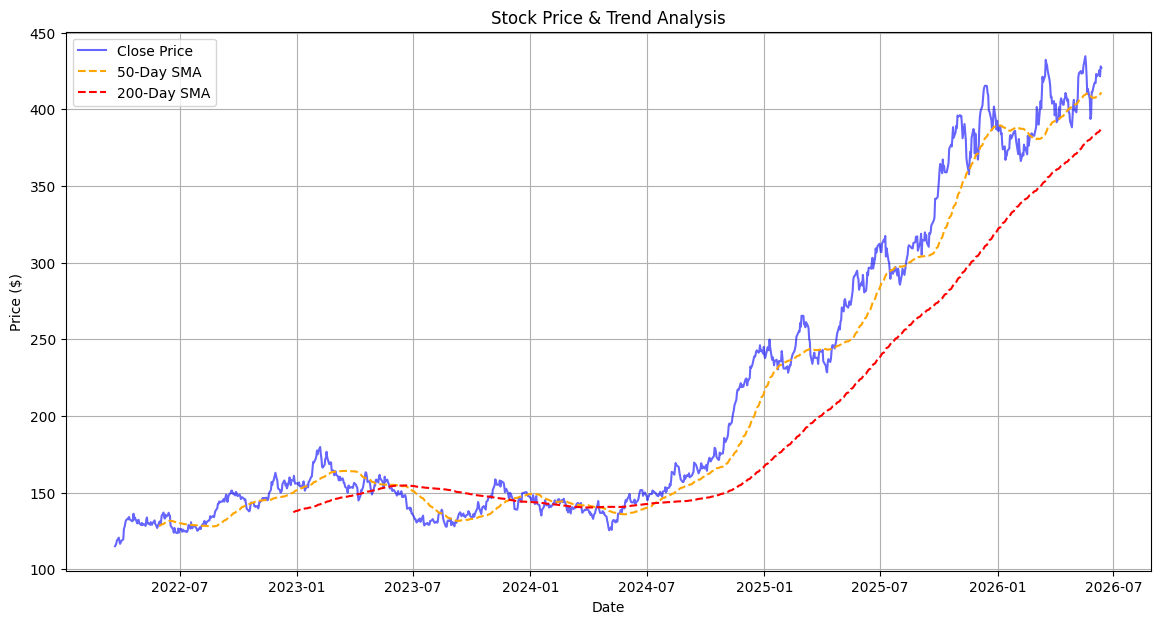

In [8]:
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['SMA_200'] = data['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', color='blue', alpha=0.6)
plt.plot(data['SMA_50'], label='50-Day SMA', color='orange', linestyle='--')
plt.plot(data['SMA_200'], label='200-Day SMA', color='red', linestyle='--')
plt.title('Stock Price & Trend Analysis')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

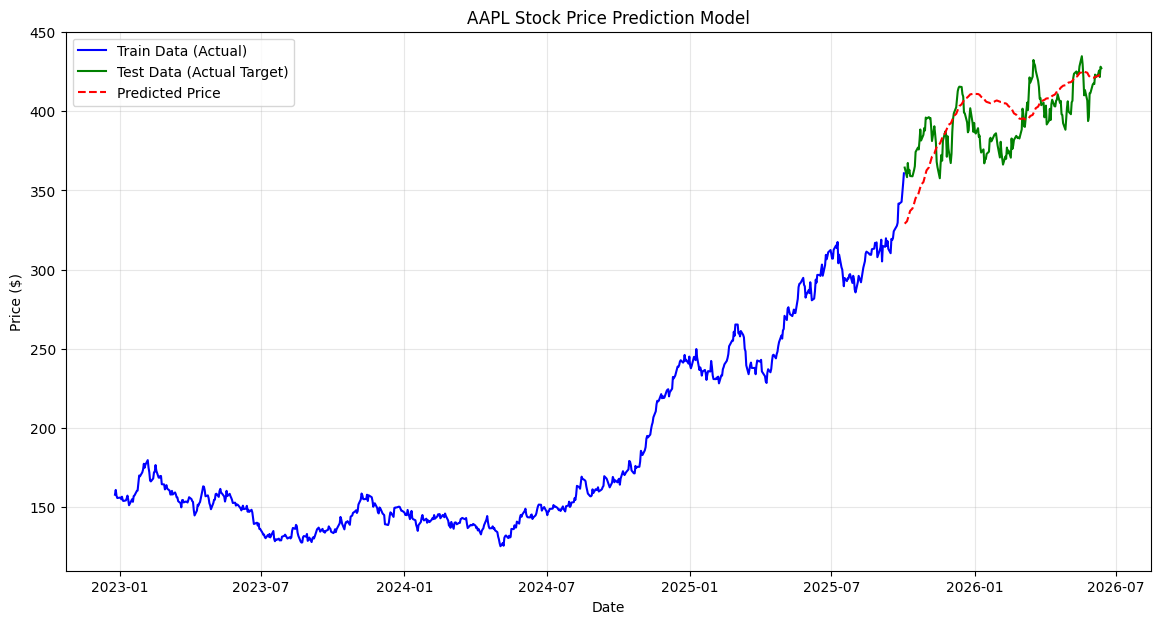

Model R² Score: -0.1250
Root Mean Squared Error (RMSE): $20.09


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = data[['SMA_50', 'SMA_200']]
y = data['Close']

combined_data = pd.concat([X, y], axis=1).dropna()
X = combined_data[['SMA_50', 'SMA_200']]
y = combined_data['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

predictions = pd.Series(y_pred, index=y_test.index)

plt.figure(figsize=(14, 7))
plt.plot(y_train, label='Train Data (Actual)', color='blue')
plt.plot(y_test, label='Test Data (Actual Target)', color='green')
plt.plot(predictions, label='Predicted Price', color='red', linestyle='--')

plt.title('AAPL Stock Price Prediction Model')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Model R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")